### Loading and Key Facts

In [1]:
import numpy as np
import glob

FEAT_DIR = "/kaggle/input/notebooks/tanyaarora29/minirocketmulti"  # update this path
# To find the exact path, run:
import os
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if "train_chunks" in f:
            print(os.path.join(root, f))

/kaggle/input/notebooks/tanyaarora29/minirocketmulti/rocket_features/train_chunks.npy


In [2]:
import numpy as np
import glob

FEAT_DIR = "/kaggle/input/notebooks/tanyaarora29/minirocketmulti/rocket_features"

# ── Check manifests
train_chunks = np.load(f"{FEAT_DIR}/train_chunks.npy")
val_chunks   = np.load(f"{FEAT_DIR}/val_chunks.npy")
test_chunks  = np.load(f"{FEAT_DIR}/test_chunks.npy")

print(f"Train chunks : {len(train_chunks)}  starts={train_chunks[:5]}")
print(f"Val chunks   : {len(val_chunks)}  starts={val_chunks[:5]}")
print(f"Test chunks  : {len(test_chunks)}  starts={test_chunks[:5]}")

# ── Check all chunk files actually exist
for split in ["train", "val", "test"]:
    chunks  = np.load(f"{FEAT_DIR}/{split}_chunks.npy")
    missing = []
    for i in chunks:
        xf = f"{FEAT_DIR}/{split}_X_{i:06d}.npy"
        yf = f"{FEAT_DIR}/{split}_y_{i:06d}.npy"
        if not os.path.exists(xf): missing.append(xf)
        if not os.path.exists(yf): missing.append(yf)
    print(f"[{split}] {len(chunks)} chunks — missing files: {len(missing)}")

# ── Check tabular splits
for split in ["train", "val", "test"]:
    t = np.load(f"{FEAT_DIR}/{split}_T.npy")
    print(f"[{split}] tabular T: {t.shape}")

Train chunks : 28  starts=[   0  500 1000 1500 2000]
Val chunks   : 6  starts=[   0  500 1000 1500 2000]
Test chunks  : 6  starts=[   0  500 1000 1500 2000]
[train] 28 chunks — missing files: 0
[val] 6 chunks — missing files: 0
[test] 6 chunks — missing files: 0
[train] tabular T: (13678, 297)
[val] tabular T: (2931, 297)
[test] tabular T: (2931, 297)


In [3]:
import pandas as pd, numpy as np
BASE   = "/kaggle/input/datasets/kimberlybertoli/aircraft-pipeline"
labels = pd.read_csv(f"{BASE}/labels.csv", index_col="Master Index")
def load_rocket(split_name):
    chunks = np.load(f"{FEAT_DIR}/{split_name}_chunks.npy")

    X_list = []
    y_list = []

    for i in chunks:
        X_list.append(
            np.load(f"{FEAT_DIR}/{split_name}_X_{i:06d}.npy")
        )
        y_list.append(
            np.load(f"{FEAT_DIR}/{split_name}_y_{i:06d}.npy")
        )

    X = np.concatenate(X_list, axis=0).astype(np.float32)
    y = np.concatenate(y_list, axis=0)

    print(
        f"  [{split_name}] rocket={X.shape}  y={y.shape}  "
        f"risk%={(y==0).mean()*100:.1f}%"
    )

    return X, y

# ── Load labels for alignment (MASTER INDEX FIX)

labels = pd.read_csv(f"{BASE}/labels.csv", index_col="Master Index")
seq_idx = np.load(f"{BASE}/seq_indices.npy")

data = labels.loc[seq_idx].copy()

idx_train = data[data["split"] == "train"].index.values
idx_val   = data[data["split"] == "val"].index.values
idx_test  = data[data["split"] == "test"].index.values

In [4]:
import os
import gc
import numpy as np

# ── Load rocket chunks
def load_rocket(split_name):
    chunks = np.load(f"{FEAT_DIR}/{split_name}_chunks.npy")

    X_list = []
    y_list = []

    for i in chunks:
        X_list.append(
            np.load(f"{FEAT_DIR}/{split_name}_X_{i:06d}.npy")
        )
        y_list.append(
            np.load(f"{FEAT_DIR}/{split_name}_y_{i:06d}.npy")
        )

    X = np.concatenate(X_list, axis=0).astype(np.float32)
    y = np.concatenate(y_list, axis=0)

    print(
        f"  [{split_name}] rocket={X.shape}  y={y.shape}  "
        f"risk%={(y==0).mean()*100:.1f}%"
    )

    return X, y

print("Loading rocket features...")
X_train_r, y_train = load_rocket("train")
X_val_r,   y_val   = load_rocket("val")
X_test_r,  y_test  = load_rocket("test")

# ── Load tabular
T_train = np.load(f"{FEAT_DIR}/train_T.npy").astype(np.float32)
T_val   = np.load(f"{FEAT_DIR}/val_T.npy").astype(np.float32)
T_test  = np.load(f"{FEAT_DIR}/test_T.npy").astype(np.float32)
print(f"\n  Tabular: {T_train.shape[1]} features")

# ── Fuse
X_train = np.concatenate([X_train_r, T_train], axis=1)
X_val   = np.concatenate([X_val_r,   T_val],   axis=1)
X_test  = np.concatenate([X_test_r,  T_test],  axis=1)
print(f"\n  Fused: train={X_train.shape}  val={X_val.shape}  test={X_test.shape}")

del X_train_r, X_val_r, X_test_r, T_train, T_val, T_test
gc.collect()

# ── Sanity check
assert X_train.shape[0] == len(y_train)
assert X_val.shape[0]   == len(y_val)
assert X_test.shape[0]  == len(y_test)
print("\n✓ All shapes consistent")

Loading rocket features...
  [train] rocket=(13678, 9996)  y=(13678,)  risk%=40.4%
  [val] rocket=(2931, 9996)  y=(2931,)  risk%=40.4%
  [test] rocket=(2931, 9996)  y=(2931,)  risk%=40.4%

  Tabular: 297 features

  Fused: train=(13678, 10293)  val=(2931, 10293)  test=(2931, 10293)

✓ All shapes consistent


In [5]:
# ── Load labels for alignment (MASTER INDEX FIX)

labels = pd.read_csv(f"{BASE}/labels.csv", index_col="Master Index")
seq_idx = np.load(f"{BASE}/seq_indices.npy")

data = labels.loc[seq_idx].copy()

idx_train = data[data["split"] == "train"].index.values
idx_val   = data[data["split"] == "val"].index.values
idx_test  = data[data["split"] == "test"].index.values

In [6]:
X_train_r, y_train = load_rocket("train")
X_val_r,   y_val   = load_rocket("val")
X_test_r,  y_test  = load_rocket("test")

  [train] rocket=(13678, 9996)  y=(13678,)  risk%=40.4%
  [val] rocket=(2931, 9996)  y=(2931,)  risk%=40.4%
  [test] rocket=(2931, 9996)  y=(2931,)  risk%=40.4%


In [7]:
# ── Load tabular (REQUIRED CELL)

T_train = np.load(f"{FEAT_DIR}/train_T.npy").astype(np.float32)
T_val   = np.load(f"{FEAT_DIR}/val_T.npy").astype(np.float32)
T_test  = np.load(f"{FEAT_DIR}/test_T.npy").astype(np.float32)

print("Tabular loaded:")
print("T_train:", T_train.shape)
print("T_val  :", T_val.shape)
print("T_test :", T_test.shape)

Tabular loaded:
T_train: (13678, 297)
T_val  : (2931, 297)
T_test : (2931, 297)


In [8]:
print("ALIGNMENT CHECK")

# 1) Basic shape checks
print("Shapes:")
print("X_train_r:", X_train_r.shape)
print("y_train   :", y_train.shape)
print("T_train   :", T_train.shape)

assert X_train_r.shape[0] == y_train.shape[0] == T_train.shape[0]
print("✓ Train shapes aligned")

assert X_val_r.shape[0] == y_val.shape[0] == T_val.shape[0]
print("✓ Val shapes aligned")

assert X_test_r.shape[0] == y_test.shape[0] == T_test.shape[0]
print("✓ Test shapes aligned")


# 2) Label sanity check (distribution consistency)
def dist(y, name):
    print(f"\n{name}")
    print("risk(0):", (y == 0).sum())
    print("safe(1):", (y == 1).sum())
    print("risk % :", (y == 0).mean() * 100)

dist(y_train, "TRAIN")
dist(y_val, "VAL")
dist(y_test, "TEST")


# 3) Check for accidental shuffling issues
# (if something is misaligned, distributions often look weird vs labels.csv)

labels = pd.read_csv(f"{BASE}/labels.csv", index_col="Master Index")
seq_idx = np.load(f"{BASE}/seq_indices.npy")
data = labels.loc[seq_idx]

print("LABEL FILE COMPARISON")

for split_name, y_local in [
    ("train", y_train),
    ("val", y_val),
    ("test", y_test)
]:
    ref = data[data["split"] == split_name]["rul_2d"].values

    print(f"\n{split_name.upper()} comparison:")
    print("loaded y:", len(y_local))
    print("label df:", len(ref))

    if len(y_local) == len(ref):
        print("match:", np.all(y_local == ref))
    else:
        print("LENGTH MISMATCH → pipeline broken")


# 4) Quick corruption check (important)
print("RANDOM SAMPLE CHECK")

for split_name, y_local in [("train", y_train), ("val", y_val)]:
    idx = np.random.choice(len(y_local), 5, replace=False)
    print(f"\n{split_name} sample:", y_local[idx])

ALIGNMENT CHECK
Shapes:
X_train_r: (13678, 9996)
y_train   : (13678,)
T_train   : (13678, 297)
✓ Train shapes aligned
✓ Val shapes aligned
✓ Test shapes aligned

TRAIN
risk(0): 5522
safe(1): 8156
risk % : 40.371399327387046

VAL
risk(0): 1183
safe(1): 1748
risk % : 40.36165131354487

TEST
risk(0): 1184
safe(1): 1747
risk % : 40.39576936199249
LABEL FILE COMPARISON

TRAIN comparison:
loaded y: 13678
label df: 13678
match: True

VAL comparison:
loaded y: 2931
label df: 2931
match: True

TEST comparison:
loaded y: 2931
label df: 2931
match: True
RANDOM SAMPLE CHECK

train sample: [0 0 1 1 1]

val sample: [0 1 0 0 1]


In [9]:
print("Train X:", X_train_r.shape)
print("Train y:", len(y_train))
print("Val X:", X_val_r.shape)
print("Val y:", len(y_val))
print("Test X:", X_test_r.shape)
print("Test y:", len(y_test))

Train X: (13678, 9996)
Train y: 13678
Val X: (2931, 9996)
Val y: 2931
Test X: (2931, 9996)
Test y: 2931


In [10]:
from sklearn.preprocessing import StandardScaler
import gc

print("Scaling fused features...")
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train); del X_train
X_val_sc   = scaler.transform(X_val);       del X_val
X_test_sc  = scaler.transform(X_test);      del X_test
gc.collect()

print(f"  X_train_sc : mean={X_train_sc.mean():.4f}  std={X_train_sc.std():.4f}")
print(f"  X_val_sc   : mean={X_val_sc.mean():.4f}  std={X_val_sc.std():.4f}")
print(f"  X_test_sc  : mean={X_test_sc.mean():.4f}  std={X_test_sc.std():.4f}")
print("✓ Scaling done")

Scaling fused features...
  X_train_sc : mean=-0.0000  std=1.0000
  X_val_sc   : mean=-0.0059  std=1.0083
  X_test_sc  : mean=0.0163  std=0.9936
✓ Scaling done


In [11]:
import pandas as pd
import numpy as np

BASE = "/kaggle/input/datasets/kimberlybertoli/aircraft-pipeline"

labels = pd.read_csv(f"{BASE}/labels.csv", index_col="Master Index")
idx    = np.load(f"{BASE}/seq_indices.npy")
split  = labels.loc[idx, "split"].values

print("Label distribution per target:\n")
for target in ["rul_2d", "rul_10d", "rul_5d"]:
    y_all = labels.loc[idx, target].values
    print(f"  {target}:")
    for sname in ["train", "val", "test"]:
        y = y_all[split == sname]
        print(f"    {sname:5s}: RISK(0)={(y==0).sum():,}  "
              f"SAFE(1)={(y==1).sum():,}  "
              f"risk%={(y==0).mean()*100:.1f}%")
    print()

Label distribution per target:

  rul_2d:
    train: RISK(0)=5,522  SAFE(1)=8,156  risk%=40.4%
    val  : RISK(0)=1,183  SAFE(1)=1,748  risk%=40.4%
    test : RISK(0)=1,184  SAFE(1)=1,747  risk%=40.4%

  rul_10d:
    train: RISK(0)=7,342  SAFE(1)=6,336  risk%=53.7%
    val  : RISK(0)=1,557  SAFE(1)=1,374  risk%=53.1%
    test : RISK(0)=1,565  SAFE(1)=1,366  risk%=53.4%

  rul_5d:
    train: RISK(0)=7,101  SAFE(1)=6,577  risk%=51.9%
    val  : RISK(0)=1,509  SAFE(1)=1,422  risk%=51.5%
    test : RISK(0)=1,509  SAFE(1)=1,422  risk%=51.5%



###  Ridge Model (without tabular)

In [12]:
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

model_ridge = RidgeClassifier(alpha=10.0, class_weight="balanced")
model_ridge.fit(X_train_r, y_train)

RidgeClassifier(alpha=10.0, class_weight='balanced')


===== TRAIN =====
Accuracy : 0.7471121508992543
Precision (Risk=0): 0.658472883699493
Recall    (Risk=0): 0.7761680550525172
F1-score  (Risk=0): 0.7124927271216025

Confusion Matrix:
[[4286 1236]
 [2223 5933]]

Classification Report:
              precision    recall  f1-score   support

    Risk (0)       0.66      0.78      0.71      5522
    Safe (1)       0.83      0.73      0.77      8156

    accuracy                           0.75     13678
   macro avg       0.74      0.75      0.74     13678
weighted avg       0.76      0.75      0.75     13678

ROC-AUC (Risk=0): 0.8272152928257543
PR-AUC  (Risk=0): 0.7474263059259387


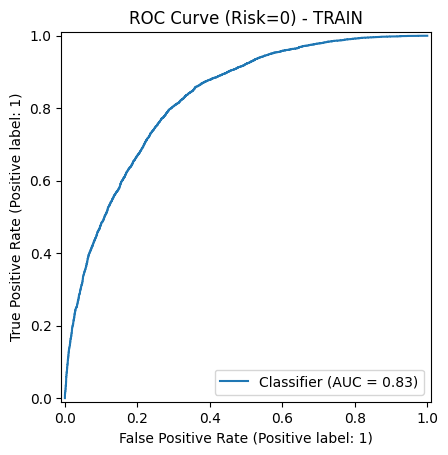

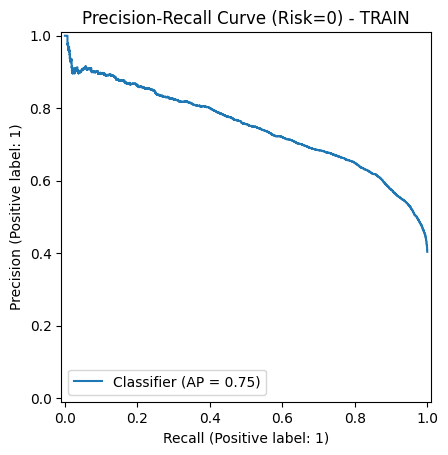

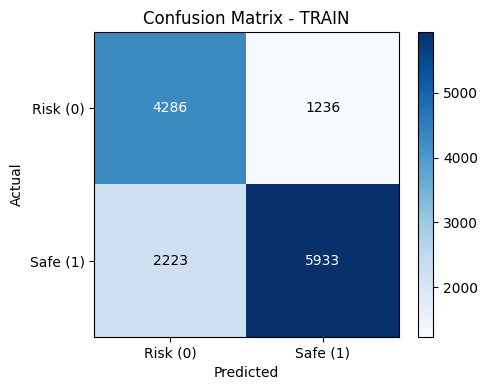


===== VAL =====
Accuracy : 0.659843056977141
Precision (Risk=0): 0.5664285714285714
Recall    (Risk=0): 0.6703296703296703
F1-score  (Risk=0): 0.6140147115756872

Confusion Matrix:
[[ 793  390]
 [ 607 1141]]

Classification Report:
              precision    recall  f1-score   support

    Risk (0)       0.57      0.67      0.61      1183
    Safe (1)       0.75      0.65      0.70      1748

    accuracy                           0.66      2931
   macro avg       0.66      0.66      0.65      2931
weighted avg       0.67      0.66      0.66      2931

ROC-AUC (Risk=0): 0.7180842832576683
PR-AUC  (Risk=0): 0.6163226652968026


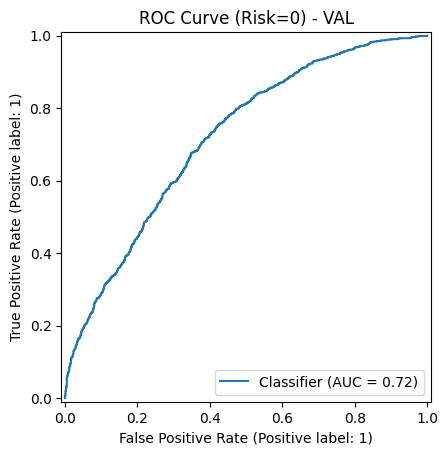

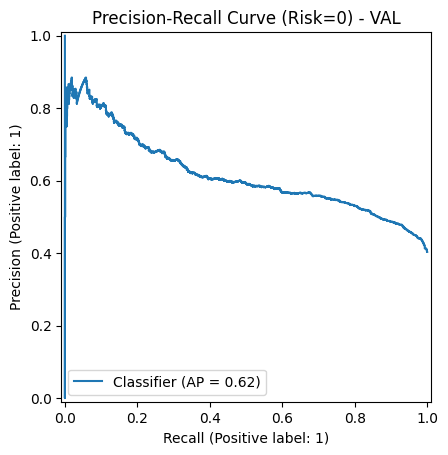

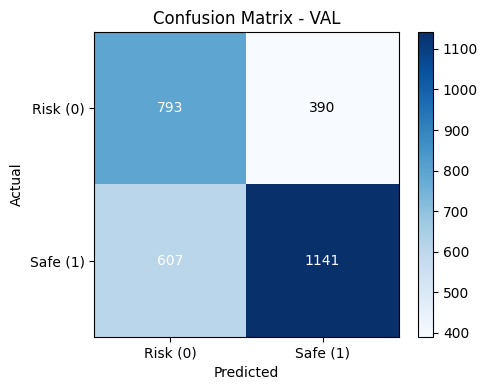


===== TEST =====
Accuracy : 0.6629136813374275
Precision (Risk=0): 0.5739064856711915
Recall    (Risk=0): 0.6427364864864865
F1-score  (Risk=0): 0.6063745019920319

Confusion Matrix:
[[ 761  423]
 [ 565 1182]]

Classification Report:
              precision    recall  f1-score   support

    Risk (0)       0.57      0.64      0.61      1184
    Safe (1)       0.74      0.68      0.71      1747

    accuracy                           0.66      2931
   macro avg       0.66      0.66      0.66      2931
weighted avg       0.67      0.66      0.67      2931

ROC-AUC (Risk=0): 0.7233295204907254
PR-AUC  (Risk=0): 0.6136323236957821


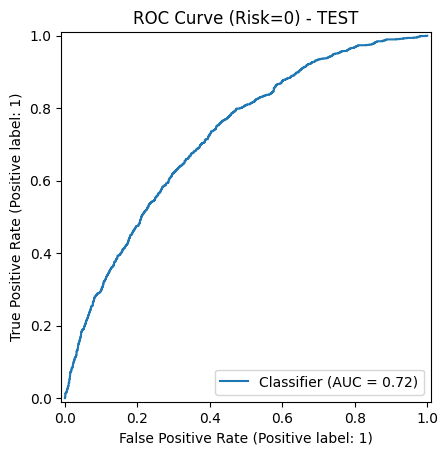

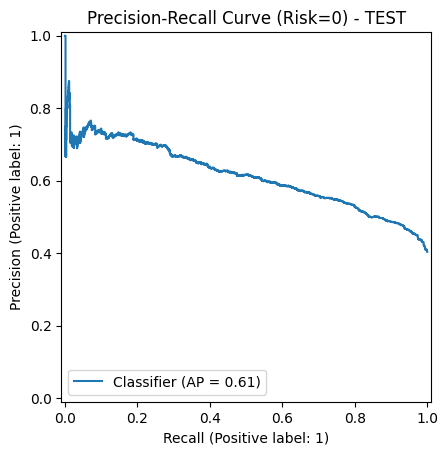

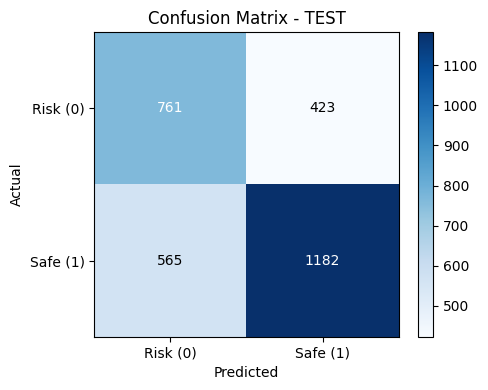

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

def evaluate(name, X, y):

    pred = model_ridge.predict(X)

    print(f"\n===== {name} =====")

    print("Accuracy :", accuracy_score(y, pred))
    print("Precision (Risk=0):", precision_score(y, pred, pos_label=0))
    print("Recall    (Risk=0):", recall_score(y, pred, pos_label=0))
    print("F1-score  (Risk=0):", f1_score(y, pred, pos_label=0))

    # Confusion Matrix
    cm = confusion_matrix(y, pred, labels=[0, 1])

    print("\nConfusion Matrix:")
    print(cm)

    print("\nClassification Report:")
    print(
        classification_report(
            y,
            pred,
            labels=[0, 1],
            target_names=["Risk (0)", "Safe (1)"]
        )
    )

    y_risk = (y == 0).astype(int)

    # Score for risk ranking
    try:
        score = model_ridge.decision_function(X)
        risk_score = -score   # higher = more risk
    except:
        score = model_ridge.predict_proba(X)[:, 1]
        risk_score = 1 - score

    # ROC-AUC (Risk-focused)
    roc = roc_auc_score(y_risk, risk_score)
    print("ROC-AUC (Risk=0):", roc)

    # PR-AUC (Risk-focused)
    pr = average_precision_score(y_risk, risk_score)
    print("PR-AUC  (Risk=0):", pr)

    # ROC Curve
    RocCurveDisplay.from_predictions(
        y_risk,
        risk_score
    )
    plt.title(f"ROC Curve (Risk=0) - {name}")
    plt.show()

    # Precision-Recall Curve
    PrecisionRecallDisplay.from_predictions(
        y_risk,
        risk_score
    )
    plt.title(f"Precision-Recall Curve (Risk=0) - {name}")
    plt.show()

    # Confusion Matrix Plot
    plt.figure(figsize=(5, 4))

    plt.imshow(cm, cmap="Blues", interpolation="nearest")
    plt.title(f"Confusion Matrix - {name}")
    plt.colorbar()

    thresh = cm.max() / 2

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i,
                format(cm[i, j], "d"),
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.xticks([0, 1], ["Risk (0)", "Safe (1)"])
    plt.yticks([0, 1], ["Risk (0)", "Safe (1)"])

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.tight_layout()
    plt.show()

# Run Evaluation
evaluate("TRAIN", X_train_r, y_train)
evaluate("VAL",   X_val_r,   y_val)
evaluate("TEST",  X_test_r,  y_test)

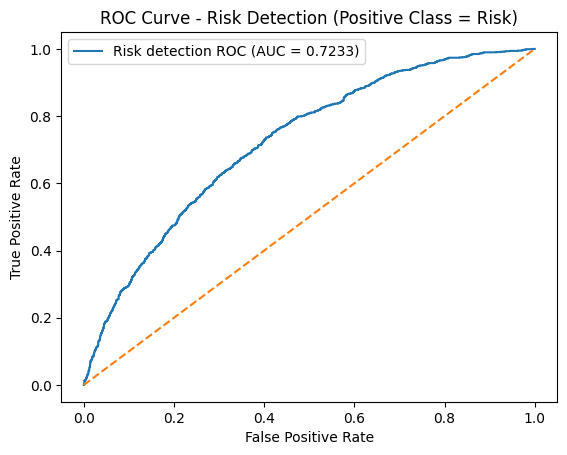

In [14]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_risk = (y_test == 0).astype(int)
score = -model_ridge.decision_function(X_test_r)

fpr, tpr, _ = roc_curve(y_risk, score)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"Risk detection ROC (AUC = {roc_auc:.4f})")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Risk Detection (Positive Class = Risk)")
plt.legend()
plt.show()

The Ridge model with MiniRocket features learns highly discriminative patterns on the training set but fails to fully generalize, resulting in a consistent performance drop (~0.25 ROC-AUC decrease) on unseen data. This suggests that improvements are more likely to come from better feature robustness or more expressive models rather than further tuning of the current linear classifier.
Logistic Regression trained on MiniRocket-only features showed slow convergence and increased computational burden due to the high-dimensional feature space, prompting the integration of tabular features to improve conditioning of the input space and enhance training stability.
We evaluate classification performance using hard labels for threshold-based metrics and continuous decision scores (not necessarily calibrated probabilities) for ranking-based metrics such as ROC-AUC and PR-AUC.

### Ridge (with tabular scaled)

In [15]:
import time
from sklearn.linear_model import RidgeClassifier

start_time = time.perf_counter()

model_rt = RidgeClassifier(
    alpha=1210.9359330652615,
    class_weight="balanced"
)

model_rt.fit(X_train_sc, y_train)

end_time = time.perf_counter()

training_time = end_time - start_time

print(f"Training time: {training_time:.4f} seconds")

Training time: 17.9712 seconds


### Run Optuna

In [16]:
import optuna
import time
def objective(trial):

    start_time = time.time()

    alpha = trial.suggest_float("alpha", 1e-3, 1e4, log=True)
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])

    model = RidgeClassifier(
        alpha=alpha,
        class_weight=class_weight,
        random_state=42
    )

    model.fit(X_train_sc, y_train)

    scores = model.decision_function(X_val_sc)
    auc = roc_auc_score(y_val, scores)

    end_time = time.time()
    duration = end_time - start_time

    # log trial time (visible in Optuna results)
    trial.set_user_attr("duration_sec", duration)

    print(f"Trial {trial.number} | AUC={auc:.4f} | time={duration:.2f}s")

    return auc

# Only run when required to avoid re-running everytime we run all cells with fixed seed for reproducibility
RUN_OPTUNA = False 

if RUN_OPTUNA:
    study_ridge = optuna.create_study(direction="maximize",sampler=optuna.samplers.TPESampler(seed=42))
    study_ridge.optimize(objective, n_trials=20)

    best_params = study_ridge.best_params
else:
    print("Skipping Optuna (using saved best_params)")

Skipping Optuna (using saved best_params)


### Evaluation 

In [17]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

# Evaluation function (Risk-focused: class 0 = Risk)

def evaluate_rt(name, model, X, y):

    pred = model.predict(X)

    print(f"\n===== {name} =====")

    print("Accuracy :", accuracy_score(y, pred))
    print("Precision (Risk=0):", precision_score(y, pred, pos_label=0))
    print("Recall    (Risk=0):", recall_score(y, pred, pos_label=0))
    print("F1-score  (Risk=0):", f1_score(y, pred, pos_label=0))

    # Confusion Matrix (explicit label order)
    cm = confusion_matrix(y, pred, labels=[0, 1]).astype(int)

    print("\nConfusion Matrix:")
    print(cm)

    print("\nClassification Report:")
    print(
        classification_report(
            y,
            pred,
            labels=[0, 1],
            target_names=["Risk (0)", "Safe (1)"]
        )
    )

    # Convert to binary risk target (Risk=0 → 1)
    y_risk = (y == 0).astype(int)

    # Get model score and convert into "risk score"
    try:
        score = model.decision_function(X)
        risk_score = -score   # higher = more risk
    except:
        score = model.predict_proba(X)[:, 1]
        risk_score = 1 - score

    # ROC-AUC (Risk-focused)
    roc = roc_auc_score(y_risk, risk_score)
    print("ROC-AUC (Risk=0):", roc)

    # PR-AUC (Risk-focused)
    pr = average_precision_score(y_risk, risk_score)
    print("PR-AUC  (Risk=0):", pr)

    # ROC Curve
    RocCurveDisplay.from_predictions(
        y_risk,
        risk_score
    )
    plt.title(f"ROC Curve (Risk=0) - {name}")
    plt.show()

    # Precision-Recall Curve
    PrecisionRecallDisplay.from_predictions(
        y_risk,
        risk_score
    )
    plt.title(f"Precision-Recall Curve (Risk=0) - {name}")
    plt.show()

    # Confusion Matrix Plot
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, cmap="Blues", interpolation="nearest")
    plt.title(f"Confusion Matrix - {name}")
    plt.colorbar()

    thresh = cm.max() / 2

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i,
                format(cm[i, j], "d"),
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.xticks([0, 1], ["Risk (0)", "Safe (1)"])
    plt.yticks([0, 1], ["Risk (0)", "Safe (1)"])

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.tight_layout()
    plt.show()


===== TRAIN =====
Accuracy : 0.7727006872349759
Precision (Risk=0): 0.6913560666137986
Recall    (Risk=0): 0.7893879029337196
F1-score  (Risk=0): 0.7371269129956878

Confusion Matrix:
[[4359 1163]
 [1946 6210]]

Classification Report:
              precision    recall  f1-score   support

    Risk (0)       0.69      0.79      0.74      5522
    Safe (1)       0.84      0.76      0.80      8156

    accuracy                           0.77     13678
   macro avg       0.77      0.78      0.77     13678
weighted avg       0.78      0.77      0.77     13678

ROC-AUC (Risk=0): 0.8533164368696686
PR-AUC  (Risk=0): 0.7790327992832526


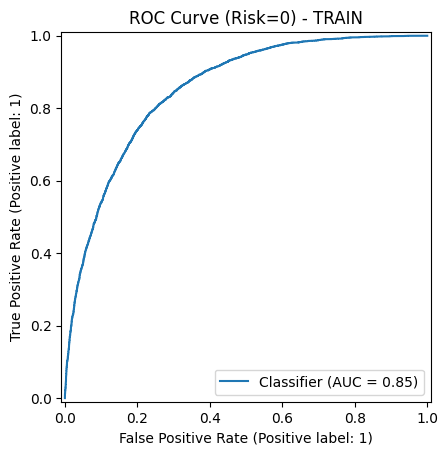

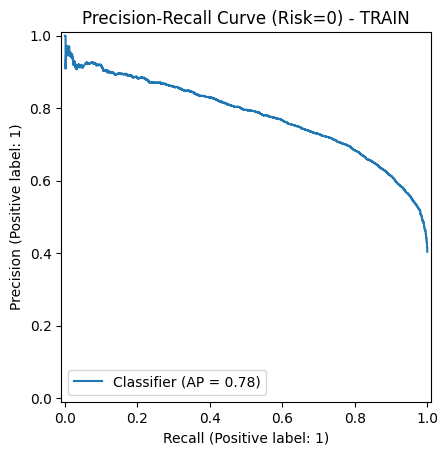

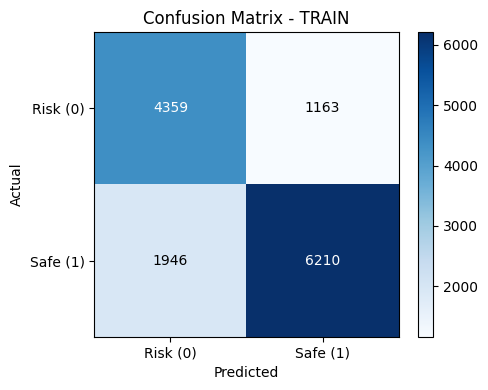


===== VAL =====
Accuracy : 0.6738314568406687
Precision (Risk=0): 0.5835172921265637
Recall    (Risk=0): 0.6703296703296703
F1-score  (Risk=0): 0.6239181746656176

Confusion Matrix:
[[ 793  390]
 [ 566 1182]]

Classification Report:
              precision    recall  f1-score   support

    Risk (0)       0.58      0.67      0.62      1183
    Safe (1)       0.75      0.68      0.71      1748

    accuracy                           0.67      2931
   macro avg       0.67      0.67      0.67      2931
weighted avg       0.68      0.67      0.68      2931

ROC-AUC (Risk=0): 0.7391947517365577
PR-AUC  (Risk=0): 0.6365309140419937


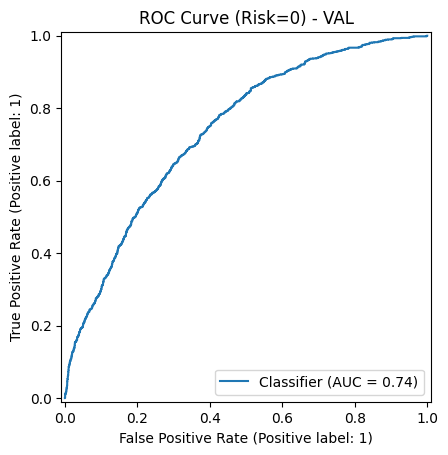

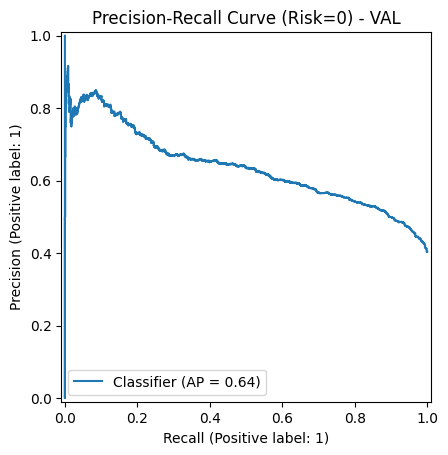

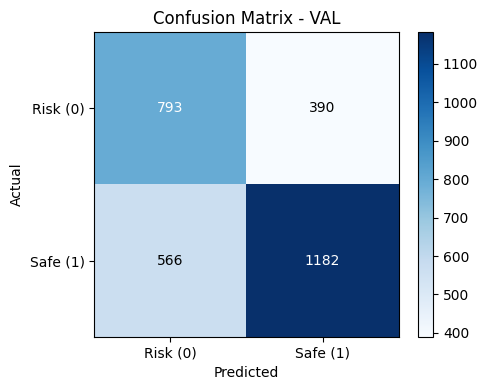


===== TEST =====
Accuracy : 0.6823609689525759
Precision (Risk=0): 0.5969348659003831
Recall    (Risk=0): 0.6579391891891891
F1-score  (Risk=0): 0.6259541984732825

Confusion Matrix:
[[ 779  405]
 [ 526 1221]]

Classification Report:
              precision    recall  f1-score   support

    Risk (0)       0.60      0.66      0.63      1184
    Safe (1)       0.75      0.70      0.72      1747

    accuracy                           0.68      2931
   macro avg       0.67      0.68      0.67      2931
weighted avg       0.69      0.68      0.68      2931

ROC-AUC (Risk=0): 0.7391802936307801
PR-AUC  (Risk=0): 0.6286051414222802


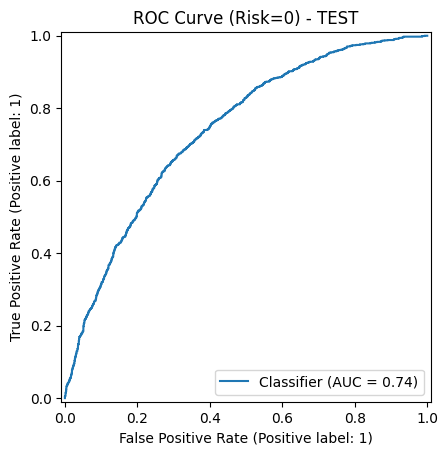

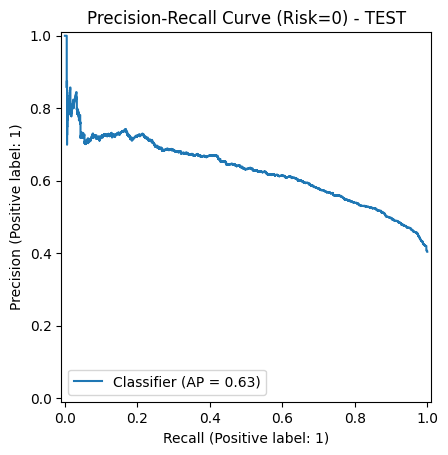

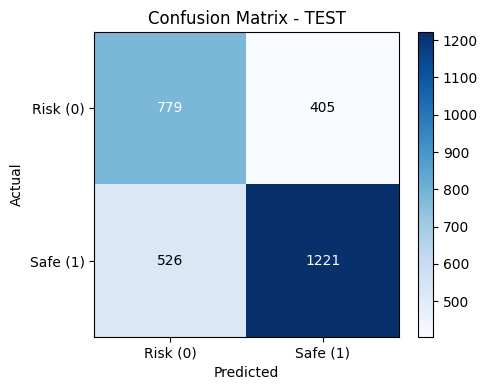

In [18]:
evaluate_rt("TRAIN", model_rt, X_train_sc, y_train)
evaluate_rt("VAL",   model_rt, X_val_sc,   y_val)
evaluate_rt("TEST",  model_rt, X_test_sc,  y_test)

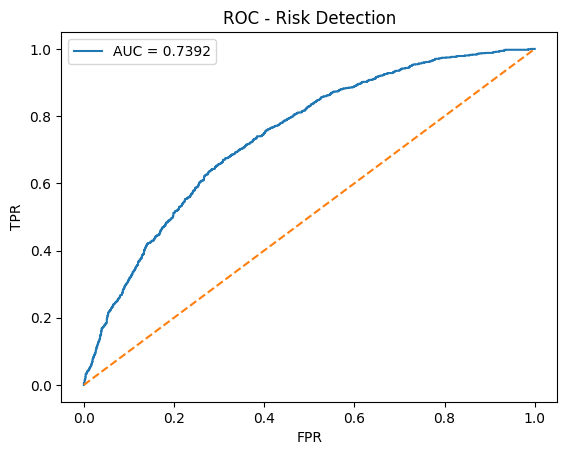

In [19]:
y_risk = (y_test == 0).astype(int)
risk_score = -model_rt.decision_function(X_test_sc)

fpr, tpr, _ = roc_curve(y_risk, risk_score)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC - Risk Detection")
plt.legend()
plt.show()

### Threshold Tuning: Optimized for F2 Score

In [20]:
from sklearn.metrics import fbeta_score, confusion_matrix
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import RidgeClassifier
import numpy as np

# Calibrate RidgeClassifier
calibrated_model_rt = CalibratedClassifierCV(
    estimator=model_rt,
    method="sigmoid",
    cv=5
)

calibrated_model_rt.fit(X_train_sc, y_train)

# Get risk probability (class 0)
proba = calibrated_model_rt.predict_proba(X_val_sc)

risk_idx_ridge = list(calibrated_model_rt.classes_).index(0)
proba_risk_ridge = proba[:, risk_idx_ridge]

# Threshold tuning
thresholds = np.linspace(0.1, 0.9, 81)

best_t = None
best_score = -1

for t in thresholds:
    
    y_pred = np.where(proba_risk_ridge >= t, 0, 1)

    score = fbeta_score(y_val, y_pred, beta=2, pos_label=0)

    if score > best_score:
        best_score = score
        best_t = t

print("Best threshold:", best_t)
print("Best F2 score:", best_score)

# Final prediction
y_pred_best = np.where(proba_risk_ridge >= best_t, 0, 1)

# Confusion matrix
cm = confusion_matrix(y_val, y_pred_best)
print("Confusion Matrix:\n", cm)

Best threshold: 0.24000000000000002
Best F2 score: 0.7889546351084813
Confusion Matrix:
 [[1120   63]
 [1246  502]]


### Threshold Sweep Table

In [21]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

rows = []

for t in np.linspace(0.1, 0.9, 81):

    # Predict Risk (class 0) when risk probability >= threshold
    y_pred = np.where(proba_risk_ridge >= t, 0, 1)

    precision = precision_score(
        y_val, y_pred,
        pos_label=0,
        zero_division=0
    )

    recall = recall_score(
        y_val, y_pred,
        pos_label=0,
        zero_division=0
    )

    f1 = f1_score(
        y_val, y_pred,
        pos_label=0,
        zero_division=0
    )

    f1_macro = f1_score(
        y_val, y_pred,
        average="macro",
        zero_division=0
    )

    accuracy = accuracy_score(y_val, y_pred)

    cm = confusion_matrix(y_val, y_pred)

    # For Risk=0 as positive:
    # [[TP FN]
    #  [FP TN]]
    TP = cm[0, 0]
    FN = cm[0, 1]
    FP = cm[1, 0]
    TN = cm[1, 1]

    false_alarms_per_100 = (
        FP / (FP + TN) * 100
        if (FP + TN) > 0 else 0
    )

    rows.append([
        t,
        precision,
        recall,
        f1,
        f1_macro,
        accuracy,
        false_alarms_per_100
    ])

operating_df = pd.DataFrame(
    rows,
    columns=[
        "threshold",
        "precision",
        "recall",
        "f1",
        "f1_macro",
        "accuracy",
        "false_alarms_per_100"
    ]
)

operating_df = operating_df.round(3)

In [22]:
best_f1 = operating_df.loc[operating_df["f1"].idxmax()]

r75 = operating_df.iloc[
    (operating_df["recall"] - 0.75).abs().idxmin()
]

r90 = operating_df.iloc[
    (operating_df["recall"] - 0.90).abs().idxmin()
]

operating_points = pd.DataFrame([
    ["Best F1", *best_f1.values],
    ["75% Recall", *r75.values],
    ["90% Recall", *r90.values]
], columns=[
    "Operating Point",
    *operating_df.columns
])

operating_points = operating_points.round(3)
operating_points

,Operating Point,threshold,precision,recall,f1,f1_macro,accuracy,false_alarms_per_100
0,Best F1,0.31,0.522,0.872,0.653,0.624,0.626,54.005
1,75% Recall,0.37,0.555,0.751,0.638,0.656,0.656,40.789
2,90% Recall,0.28,0.497,0.901,0.641,0.585,0.593,61.613


### Evaluation of F2 Optimized

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay
)


def evaluate_tab(name, X, y, model, threshold=0.5):

    RISK_CLASS = 0

    # Probabilities
    proba = model.predict_proba(X)

    risk_idx = list(model.classes_).index(RISK_CLASS)
    scores = proba[:, risk_idx]

    # Predict Risk (0) if risk probability >= threshold
    preds = np.where(scores >= threshold, 0, 1)

    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    print(f"Threshold used: {threshold:.4f}")

    # Metrics
    print("\nMetrics")
    print("Accuracy :", round(accuracy_score(y, preds), 4))
    print("Precision:", round(
        precision_score(y, preds, pos_label=RISK_CLASS, zero_division=0), 4
    ))
    print("Recall   :", round(
        recall_score(y, preds, pos_label=RISK_CLASS, zero_division=0), 4
    ))
    print("F1-score :", round(
        f1_score(y, preds, pos_label=RISK_CLASS, zero_division=0), 4
    ))

    # Classification Report
    print("\nClassification Report:")
    print(
        classification_report(
            y,
            preds,
            labels=[0, 1],
            target_names=["Risk", "Safe"],
            zero_division=0
        )
    )

    # Confusion Matrix
    cm = confusion_matrix(y, preds)

    print("\nConfusion Matrix:")
    print(cm)

    # ROC / PR need positive class = Risk
    y_risk = (y == RISK_CLASS).astype(int)

    roc = roc_auc_score(y_risk, scores)
    pr = average_precision_score(y_risk, scores)

    print("ROC-AUC  :", round(roc, 4))
    print("PR-AUC   :", round(pr, 4))

    # ROC Curve
    fig, ax = plt.subplots(figsize=(6, 5))

    RocCurveDisplay.from_predictions(
        y_risk,
        scores,
        ax=ax
    )

    ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
    ax.set_title(f"ROC Curve - {name}")

    plt.show()

    # Precision Recall Curve
    PrecisionRecallDisplay.from_predictions(
        y_risk,
        scores
    )

    plt.title(f"Precision-Recall Curve - {name}")
    plt.show()

    # Confusion Matrix Heatmap (COUNTS)
    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        xticklabels=["Pred Risk", "Pred Safe"],
        yticklabels=["True Risk", "True Safe"]
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return preds, scores


Ridge - Train
Threshold used: 0.2400

Metrics
Accuracy : 0.5943
Precision: 0.4988
Recall   : 0.9835
F1-score : 0.6619

Classification Report:
              precision    recall  f1-score   support

        Risk       0.50      0.98      0.66      5522
        Safe       0.97      0.33      0.49      8156

    accuracy                           0.59     13678
   macro avg       0.73      0.66      0.58     13678
weighted avg       0.78      0.59      0.56     13678


Confusion Matrix:
[[5431   91]
 [5458 2698]]
ROC-AUC  : 0.8453
PR-AUC   : 0.7687


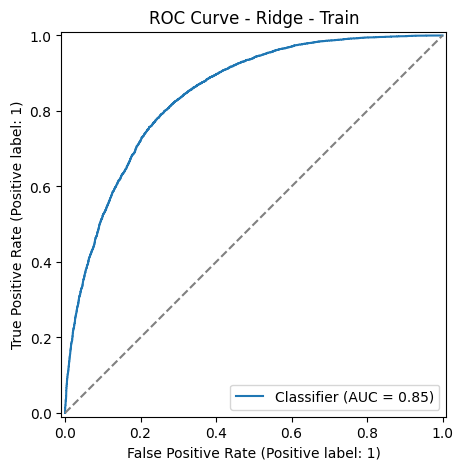

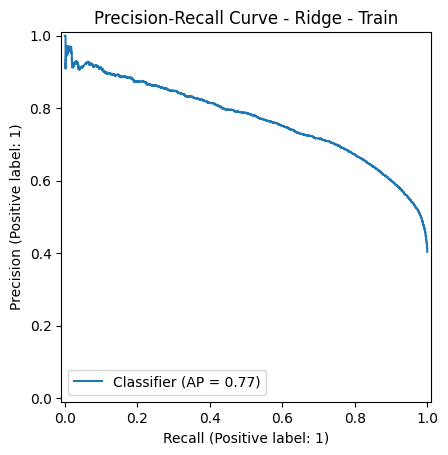

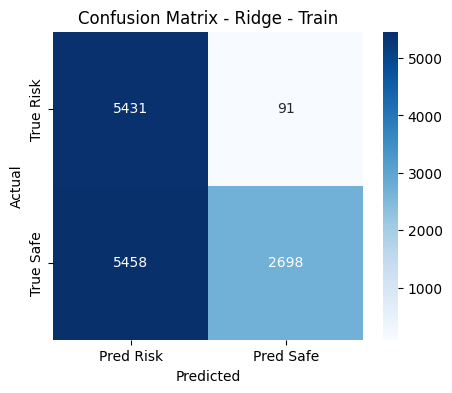


Ridge - Validation
Threshold used: 0.2400

Metrics
Accuracy : 0.5534
Precision: 0.4734
Recall   : 0.9467
F1-score : 0.6312

Classification Report:
              precision    recall  f1-score   support

        Risk       0.47      0.95      0.63      1183
        Safe       0.89      0.29      0.43      1748

    accuracy                           0.55      2931
   macro avg       0.68      0.62      0.53      2931
weighted avg       0.72      0.55      0.51      2931


Confusion Matrix:
[[1120   63]
 [1246  502]]
ROC-AUC  : 0.7382
PR-AUC   : 0.637


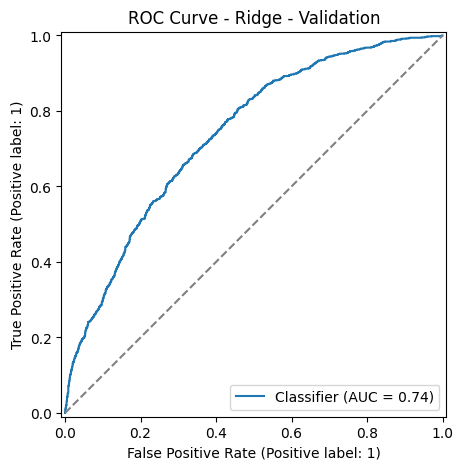

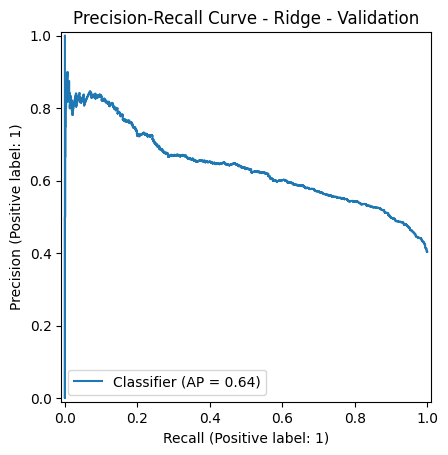

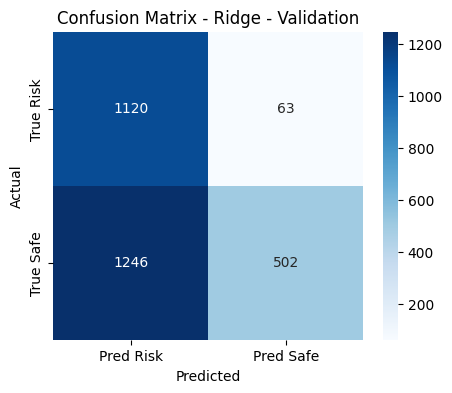


Ridge - Test
Threshold used: 0.2400

Metrics
Accuracy : 0.5493
Precision: 0.4712
Recall   : 0.9459
F1-score : 0.629

Classification Report:
              precision    recall  f1-score   support

        Risk       0.47      0.95      0.63      1184
        Safe       0.88      0.28      0.43      1747

    accuracy                           0.55      2931
   macro avg       0.68      0.61      0.53      2931
weighted avg       0.72      0.55      0.51      2931


Confusion Matrix:
[[1120   64]
 [1257  490]]
ROC-AUC  : 0.7387
PR-AUC   : 0.6289


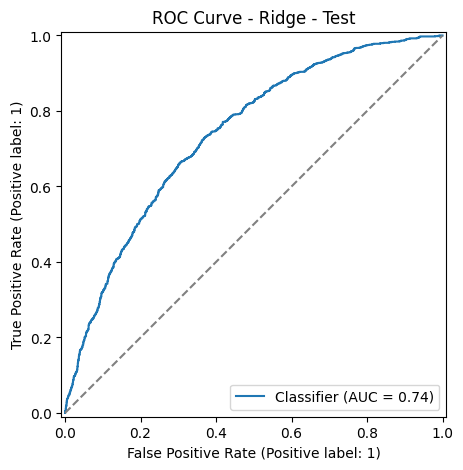

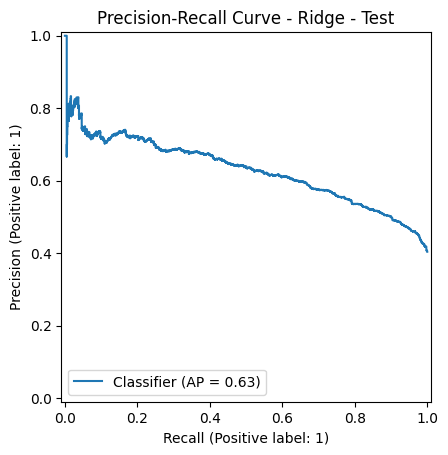

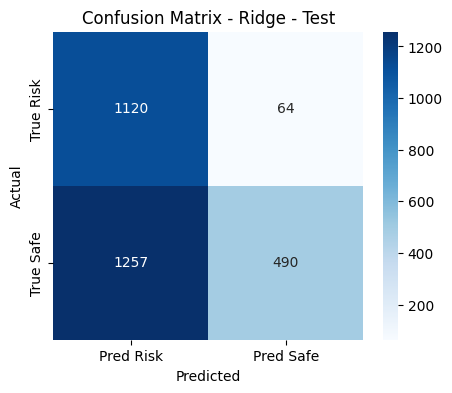

In [24]:
# TRAIN
preds_train, scores_train = evaluate_tab(
    name="Ridge - Train",
    X=X_train_sc,
    y=y_train,
    model=calibrated_model_rt,
    threshold=best_t
)

# VALIDATION
preds_val, scores_val = evaluate_tab(
    name="Ridge - Validation",
    X=X_val_sc,
    y=y_val,
    model=calibrated_model_rt,
    threshold=best_t
)

# TEST
preds_test, scores_test = evaluate_tab(
    name="Ridge - Test",
    X=X_test_sc,
    y=y_test,
    model=calibrated_model_rt,
    threshold=best_t
)

### Logistic Regression

In [25]:
from sklearn.linear_model import LogisticRegression
import time

start = time.time()

log_model = LogisticRegression(
    C=0.0050128093018505125,                  # stronger regularization
    class_weight='balanced',
    tol=5.2337981957724996e-05,
    solver="lbfgs",
    max_iter=5000,
    n_jobs=-1,
    random_state=42
)

log_model.fit(X_train_sc, y_train)

print(f"Training time: {time.time()-start:.1f} sec")

Training time: 86.2 sec


MiniRocket generates dense transformed features. LBFGS is a stable second-order optimization method that efficiently optimizes Logistic Regression with L2 regularization and generally converges faster than stochastic methods on dense feature spaces.

### Saving predictions

In [26]:
# PREDICT PROBABILITIES
proba_train = log_model.predict_proba(X_train_sc)
proba_val   = log_model.predict_proba(X_val_sc)
proba_test  = log_model.predict_proba(X_test_sc)

risk_idx = list(log_model.classes_).index(0)

proba_train_risk = proba_train[:, risk_idx]
proba_val_risk   = proba_val[:, risk_idx]
proba_test_risk  = proba_test[:, risk_idx]


# BUILD DATAFRAMES
df_train = pd.DataFrame({
    "master_index": idx_train,
    "y_true": y_train,
    "proba_risk": proba_train_risk,
    "split": "train"
})

df_val = pd.DataFrame({
    "master_index": idx_val,
    "y_true": y_val,
    "proba_risk": proba_val_risk,
    "split": "val"
})

df_test = pd.DataFrame({
    "master_index": idx_test,
    "y_true": y_test,
    "proba_risk": proba_test_risk,
    "split": "test"
})


# SAVE FILES
df_train.to_csv("logreg_train.csv", index=False)
df_val.to_csv("logreg_val.csv", index=False)
df_test.to_csv("logreg_test.csv", index=False)

print("✓ Export complete:")
print("  logreg_train.csv")
print("  logreg_val.csv")
print("  logreg_test.csv")

✓ Export complete:
  logreg_train.csv
  logreg_val.csv
  logreg_test.csv


In [27]:
import pandas as pd

# LOAD FILES
train_df = pd.read_csv("logreg_train.csv")
val_df   = pd.read_csv("logreg_val.csv")
test_df  = pd.read_csv("logreg_test.csv")

# MERGE
merged_df = pd.concat([train_df, val_df, test_df], axis=0)

# SORT BY MASTER INDEX
merged_df = merged_df.sort_values("master_index").reset_index(drop=True)

# SANITY CHECK
print("Merged shape:", merged_df.shape)
print("\nSplit counts:")
print(merged_df["split"].value_counts())

print("\nFirst 10 rows:")
print(merged_df.head(10))

# SAVE
merged_df.to_csv("logreg_all_merged_sorted.csv", index=False)

print("\n✓ Saved: logreg_all_merged_sorted.csv")

Merged shape: (19540, 4)

Split counts:
split
train    13678
val       2931
test      2931
Name: count, dtype: int64

First 10 rows:
   master_index  y_true  proba_risk  split
0             1       0    0.500982  train
1             2       0    0.448566    val
2             7       1    0.202186  train
3             9       0    0.422668   test
4            11       1    0.119830  train
5            13       1    0.772970   test
6            16       0    0.892732   test
7            17       1    0.559300  train
8            18       1    0.383856  train
9            20       1    0.125836  train

✓ Saved: logreg_all_merged_sorted.csv


### Evaluation

In [28]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay
)


def evaluate_lr_risk(name, model, X, y, threshold=0.5):

    proba = model.predict_proba(X)

    risk_idx = list(model.classes_).index(0)
    risk_score = proba[:, risk_idx]

    # Predict Risk (0) if risk probability >= threshold
    pred = np.where(risk_score >= threshold, 0, 1)

    print(f"\n===== {name} =====")
    print(f"Threshold used: {threshold}")
    print("Risk = class 0")

    print("Accuracy :", accuracy_score(y, pred))
    print("Precision:", precision_score(y, pred, pos_label=0, zero_division=0))
    print("Recall   :", recall_score(y, pred, pos_label=0, zero_division=0))
    print("F1-score :", f1_score(y, pred, pos_label=0, zero_division=0))

    # CONFUSION MATRIX
    cm = confusion_matrix(y, pred).astype(int)

    print("\nConfusion Matrix:")
    print(cm)

    print("\nClassification Report:")
    print(
        classification_report(
            y,
            pred,
            labels=[0, 1],
            target_names=["Risk", "Safe"],
            zero_division=0
        )
    )

    # AUC (Risk as positive)
    y_risk = (y == 0).astype(int)

    roc = roc_auc_score(y_risk, risk_score)
    pr = average_precision_score(y_risk, risk_score)

    print("ROC-AUC  :", roc)
    print("PR-AUC   :", pr)

    # ROC CURVE
    RocCurveDisplay.from_predictions(y_risk, risk_score)
    plt.title(f"ROC Curve - {name} (Risk=Positive)")
    plt.show()

    # PR CURVE
    PrecisionRecallDisplay.from_predictions(y_risk, risk_score)
    plt.title(f"PR Curve - {name} (Risk=Positive)")
    plt.show()

    # CONFUSION MATRIX PLOT
    plt.figure()
    plt.imshow(cm, cmap="Blues", interpolation="nearest")
    plt.title(f"Confusion Matrix - {name}")
    plt.colorbar()

    thresh_val = cm.max() / 2

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i,
                format(cm[i, j], "d"),
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh_val else "black"
            )

    plt.xticks([0, 1], ["Risk", "Safe"])
    plt.yticks([0, 1], ["Risk", "Safe"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

    return pred, risk_score


===== Train =====
Threshold used: 0.5
Risk = class 0
Accuracy : 0.7789150460593655
Precision: 0.7011920103092784
Recall   : 0.7883013400941687
F1-score : 0.7421994884910486

Confusion Matrix:
[[4353 1169]
 [1855 6301]]

Classification Report:
              precision    recall  f1-score   support

        Risk       0.70      0.79      0.74      5522
        Safe       0.84      0.77      0.81      8156

    accuracy                           0.78     13678
   macro avg       0.77      0.78      0.77     13678
weighted avg       0.79      0.78      0.78     13678

ROC-AUC  : 0.8601261945840961
PR-AUC   : 0.788819449649092


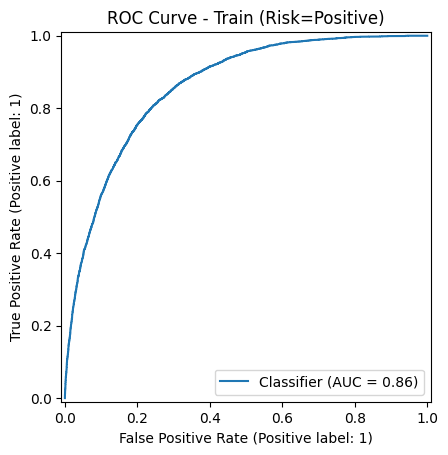

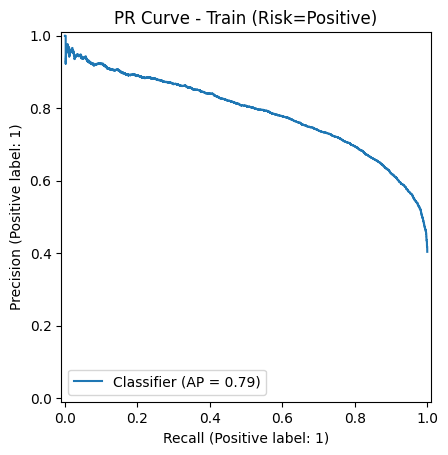

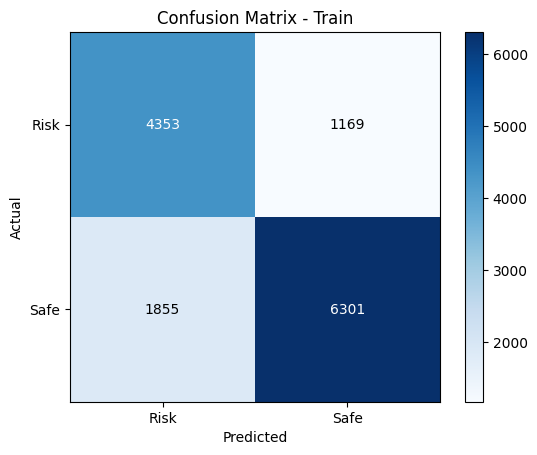


===== Validation =====
Threshold used: 0.5
Risk = class 0
Accuracy : 0.6755373592630501
Precision: 0.5876132930513596
Recall   : 0.6576500422654269
F1-score : 0.6206621459912246

Confusion Matrix:
[[ 778  405]
 [ 546 1202]]

Classification Report:
              precision    recall  f1-score   support

        Risk       0.59      0.66      0.62      1183
        Safe       0.75      0.69      0.72      1748

    accuracy                           0.68      2931
   macro avg       0.67      0.67      0.67      2931
weighted avg       0.68      0.68      0.68      2931

ROC-AUC  : 0.7385070922740348
PR-AUC   : 0.6385509878929858


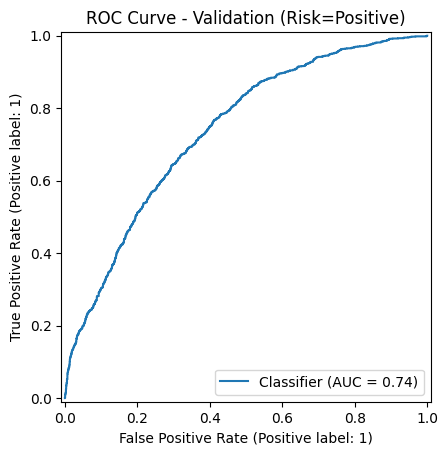

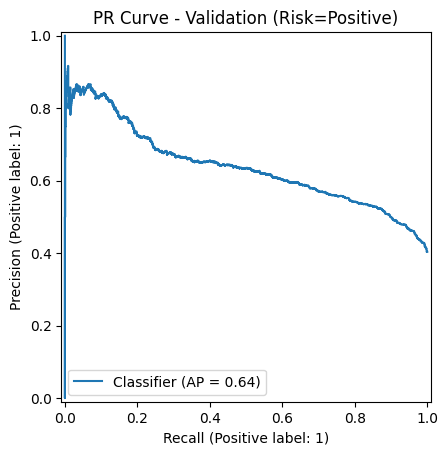

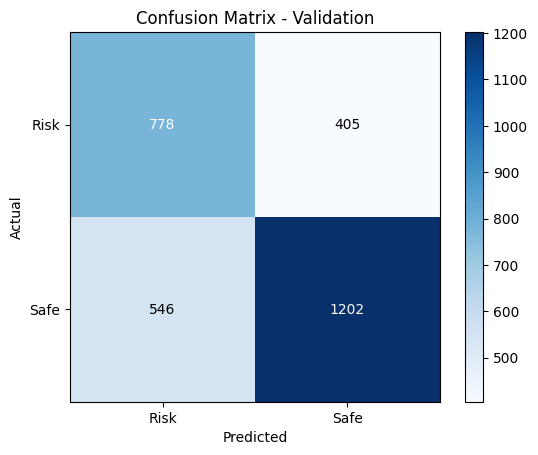


===== Test =====
Threshold used: 0.5
Risk = class 0
Accuracy : 0.6833845104060048
Precision: 0.6004709576138147
Recall   : 0.6461148648648649
F1-score : 0.6224572823433686

Confusion Matrix:
[[ 765  419]
 [ 509 1238]]

Classification Report:
              precision    recall  f1-score   support

        Risk       0.60      0.65      0.62      1184
        Safe       0.75      0.71      0.73      1747

    accuracy                           0.68      2931
   macro avg       0.67      0.68      0.67      2931
weighted avg       0.69      0.68      0.68      2931

ROC-AUC  : 0.7395356325128792
PR-AUC   : 0.6334576694449421


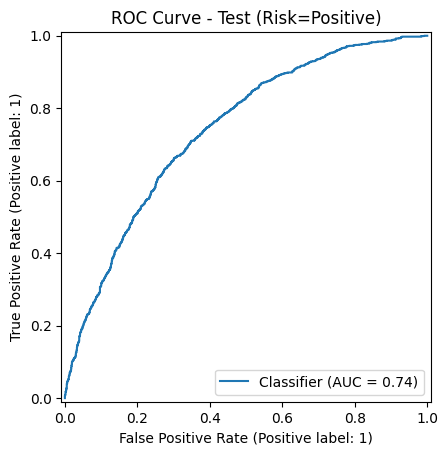

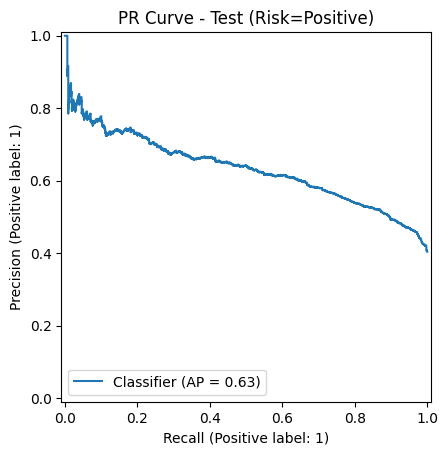

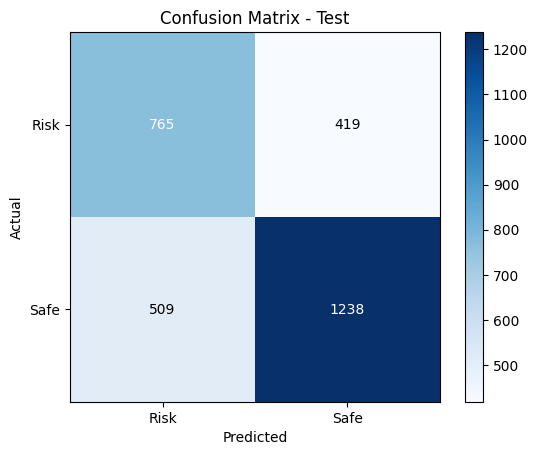

In [29]:
pred_train, proba_train = evaluate_lr_risk(
    "Train",
    log_model,
    X_train_sc,
    y_train,
    threshold=0.5
)

pred_val, proba_val = evaluate_lr_risk(
    "Validation",
    log_model,
    X_val_sc,
    y_val,
    threshold=0.5
)

pred_test, proba_test = evaluate_lr_risk(
    "Test",
    log_model,
    X_test_sc,
    y_test,
    threshold=0.5
)

In [30]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

def evaluate_lr_risk(name, model, X, y, split,threshold=0.5):

    proba = model.predict_proba(X)

    risk_idx = list(model.classes_).index(0)
    risk_score = proba[:, risk_idx]

    pred = np.where(risk_score >= threshold, 0, 1)

    # FIX: enforce consistent order
    cm = confusion_matrix(y, pred, labels=[0, 1])

    TP = cm[0, 0]  # correct risk detected
    FN = cm[0, 1]  # missed risk 
    FP = cm[1, 0]  # false alarm
    TN = cm[1, 1]

    false_alarms_per_100 = (FP / (FP + TN) * 100) if (FP + TN) > 0 else 0
    missed_risks_per_100 = (FN / (FN + TP) * 100) if (FN + TP) > 0 else 0

    y_risk = (y == 0).astype(int)

    return {
        "Split": split,
        "Accuracy": accuracy_score(y, pred),
        "Precision (Risk)": precision_score(y, pred, pos_label=0, zero_division=0),
        "Recall (Risk)": recall_score(y, pred, pos_label=0, zero_division=0),
        "F1 (Risk)": f1_score(y, pred, pos_label=0, zero_division=0),
        "ROC-AUC": roc_auc_score(y_risk, risk_score),
        "PR-AUC": average_precision_score(y_risk, risk_score),
        "False Alarms / 100": round(false_alarms_per_100),
        "Missed Risks / 100": round(missed_risks_per_100)
    }

results = []
results.append(evaluate_lr_risk("LogReg", log_model, X_train_sc, y_train,"Train"))
results.append(evaluate_lr_risk("LogReg", log_model, X_val_sc, y_val,"Val"))
results.append(evaluate_lr_risk("LogReg", log_model, X_test_sc, y_test,"Test"))

df_results = pd.DataFrame(results).round(4)
df_results

,Split,Accuracy,Precision (Risk),Recall (Risk),F1 (Risk),ROC-AUC,PR-AUC,False Alarms / 100,Missed Risks / 100
0,Train,0.7789,0.7012,0.7883,0.7422,0.8601,0.7888,23,21
1,Val,0.6755,0.5876,0.6577,0.6207,0.7385,0.6386,31,34
2,Test,0.6834,0.6005,0.6461,0.6225,0.7395,0.6335,29,35


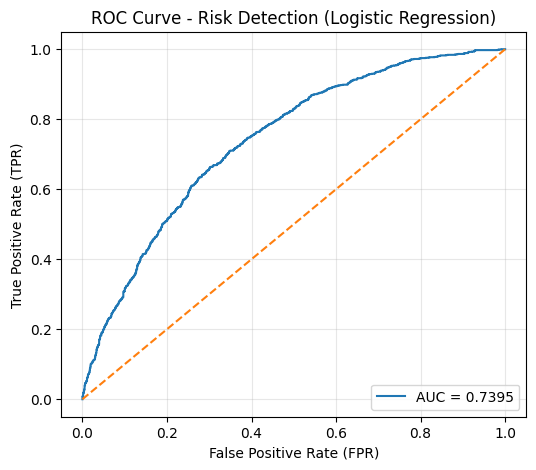

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Convert labels: Risk (0) = positive class
y_risk = (y_test == 0).astype(int)

# Get risk probability (class 0)
risk_idx = list(log_model.classes_).index(0)
risk_score = log_model.predict_proba(X_test_sc)[:, risk_idx]

# ROC curve
fpr, tpr, _ = roc_curve(y_risk, risk_score)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve - Risk Detection (Logistic Regression)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

### Optuna

In [32]:
import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

def objective(trial):

    # ---- search space ----
    C = trial.suggest_float("C", 1e-4, 10.0, log=True)

    class_weight = trial.suggest_categorical(
        "class_weight",
        [None, "balanced"]
    )

    tol = trial.suggest_float("tol", 1e-5, 1e-3, log=True)

    max_iter = trial.suggest_categorical(
        "max_iter",
        [500, 1000, 2000, 5000]
    )

    solver = "lbfgs"

    model = LogisticRegression(
        C=C,
        class_weight=class_weight,
        solver=solver,
        tol=tol,
        max_iter=max_iter,
        n_jobs=-1,
        random_state=42
    )

    # ---- train ----
    model.fit(X_train_sc, y_train)

    # ---- validation ----
    scores = model.predict_proba(X_val_sc)[:, 1]

    auc = roc_auc_score(y_val, scores)

    return auc
    
# Only run when required to avoid re-running everytime we run all cells with fixed seed for reproducibility
RUN_OPTUNA_LR = False 

if RUN_OPTUNA_LR:
    study_log= optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
    study_log.optimize(objective, n_trials=20, show_progress_bar=True)

    best_params = study_ridge.best_params
else:
    print("Skipping Optuna (using saved best_params)")

Skipping Optuna (using saved best_params)


### Threshold Sweep Table

In [33]:
proba_risk_log = log_model.predict_proba(X_val_sc)

risk_idx_log = list(log_model.classes_).index(0)
proba_risk_log = proba_risk_log[:, risk_idx_log]

import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

rows = []

for t in np.linspace(0.1, 0.9, 81):

    # Predict Risk (0) if prob >= threshold
    y_pred = np.where(proba_risk_log >= t, 0, 1)

    precision = precision_score(y_val, y_pred, pos_label=0, zero_division=0)
    recall = recall_score(y_val, y_pred, pos_label=0, zero_division=0)
    f1 = f1_score(y_val, y_pred, pos_label=0, zero_division=0)
    acc = accuracy_score(y_val, y_pred)

    f1_macro = f1_score(y_val, y_pred, average="macro", zero_division=0)

    cm = confusion_matrix(y_val, y_pred)

    TP = cm[0, 0]
    FN = cm[0, 1]
    FP = cm[1, 0]
    TN = cm[1, 1]

    false_alarms_per_100 = (FP / (FP + TN) * 100) if (FP + TN) > 0 else 0
    missed_risks_per_100 = (FN / (FN + TP) * 100) if (FN + TP) > 0 else 0

    rows.append([
        t,
        precision,
        recall,
        f1,
        f1_macro,
        acc,
        int(false_alarms_per_100),
        int(missed_risks_per_100)
    ])

log_operating_df = pd.DataFrame(rows, columns=[
    "threshold",
    "precision",
    "recall",
    "f1",
    "f1_macro",
    "accuracy",
    "false_alarms_per_100",
    "missed_risks_per_100"
])

In [34]:
best_f1 = log_operating_df.loc[log_operating_df["f1"].idxmax()]

r75 = log_operating_df.iloc[
    (log_operating_df["recall"] - 0.75).abs().idxmin()
]

r90 = log_operating_df.iloc[
    (log_operating_df["recall"] - 0.90).abs().idxmin()
]

log_op_table = pd.DataFrame([
    ["Best F1", *best_f1.values],
    ["Recall ~75%", *r75.values],
    ["Recall ~90%", *r90.values]
], columns=[
    "Operating Point",
    *log_operating_df.columns
])

log_op_table = log_op_table.round(3)

log_op_table

,Operating Point,threshold,precision,recall,f1,f1_macro,accuracy,false_alarms_per_100,missed_risks_per_100
0,Best F1,0.35,0.527,0.861,0.654,0.631,0.632,52.0,13.0
1,Recall ~75%,0.44,0.559,0.749,0.640,0.659,0.661,39.0,25.0
2,Recall ~90%,0.30,0.502,0.897,0.644,0.594,0.600,60.0,10.0


### F2 Optimized Threshold

In [35]:
from sklearn.metrics import fbeta_score
import numpy as np

# Risk = positive class
y_risk = (y_val == 0).astype(int)

# Validation probabilities
proba = log_model.predict_proba(X_val_sc)

# Probability of Risk class (class = 0)
proba_risk = proba[:, list(log_model.classes_).index(0)]

# Threshold tuning (F2 score)
thresholds = np.linspace(0.1, 0.9, 81)

best_t_log = None
best_score_log = -1

for t in thresholds:

    # Predict Risk when P(Risk) >= threshold
    y_pred = (proba_risk >= t).astype(int)

    score = fbeta_score(y_risk, y_pred, beta=2)

    if score > best_score_log:
        best_score_log = score
        best_t_log = t

print("Best threshold:", best_t_log)
print("Best F2 score:", best_score_log)

# Final predictions at optimal threshold
y_pred_best_log = (proba_risk >= best_t_log).astype(int)

Best threshold: 0.2
Best F2 score: 0.7899847412956027


### F2 Optimized Threshold Evaluation

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay
)


def evaluate_logistic(name, X, y, model, threshold=0.5):

    RISK_CLASS = 0

    # probabilities
    proba = model.predict_proba(X)

    risk_idx = list(model.classes_).index(RISK_CLASS)
    scores = proba[:, risk_idx]

    # predictions: 1 = Risk, 0 = Safe (temporary)
    preds = np.where(scores >= threshold, 1, 0)

    # remap back to original labels (0=Risk, 1=Safe)
    preds_label = np.where(preds == 1, 0, 1)

    print(f"\n===== {name} =====")
    print(f"Threshold used: {threshold}")

    # METRICS (Risk = positive class)
    print("Accuracy :", accuracy_score(y, preds_label))
    print("Precision:", precision_score(y, preds_label, pos_label=0, zero_division=0))
    print("Recall   :", recall_score(y, preds_label, pos_label=0, zero_division=0))
    print("F1-score :", f1_score(y, preds_label, pos_label=0, zero_division=0))

    print("\nClassification Report:")
    print(
        classification_report(
            y,
            preds_label,
            labels=[0, 1],
            target_names=["Risk", "Safe"],
            zero_division=0
        )
    )

    # AUC (Risk as positive)
    y_risk = (y == RISK_CLASS).astype(int)

    roc = roc_auc_score(y_risk, scores)
    pr = average_precision_score(y_risk, scores)

    print("ROC-AUC  :", roc)
    print("PR-AUC   :", pr)

    # ROC curve
    fig, ax = plt.subplots(figsize=(6, 5))

    RocCurveDisplay.from_predictions(
        y_risk,
        scores,
        ax=ax
    )

    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
    ax.set_title(f"ROC Curve - {name} (Risk = Positive)")
    plt.show()

    # PR curve
    PrecisionRecallDisplay.from_predictions(
        y_risk,
        scores
    )

    plt.title(f"PR Curve - {name}")
    plt.show()

    # CONFUSION MATRIX 
    cm = confusion_matrix(y, preds_label)

    print("\nConfusion Matrix:")
    print(cm)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",          
        cmap="Blues",
        cbar=True,
        xticklabels=["Pred Risk", "Pred Safe"],
        yticklabels=["True Risk", "True Safe"]
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return preds_label, scores


===== Logistic Regression - Train =====
Threshold used: 0.2
Accuracy : 0.5606813861675684
Precision: 0.47870945177931273
Recall   : 0.9914885910901847
F1-score : 0.6456748629046524

Classification Report:
              precision    recall  f1-score   support

        Risk       0.48      0.99      0.65      5522
        Safe       0.98      0.27      0.42      8156

    accuracy                           0.56     13678
   macro avg       0.73      0.63      0.53     13678
weighted avg       0.78      0.56      0.51     13678

ROC-AUC  : 0.8601261945840961
PR-AUC   : 0.788819449649092


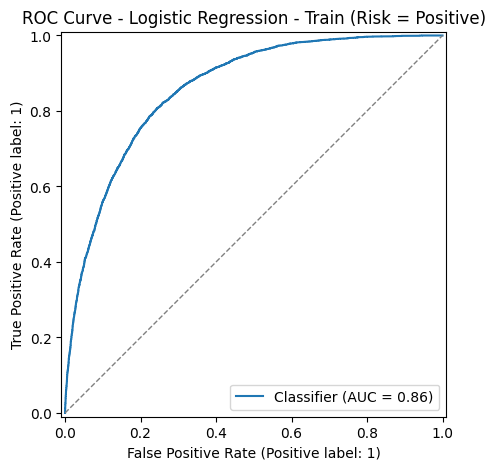

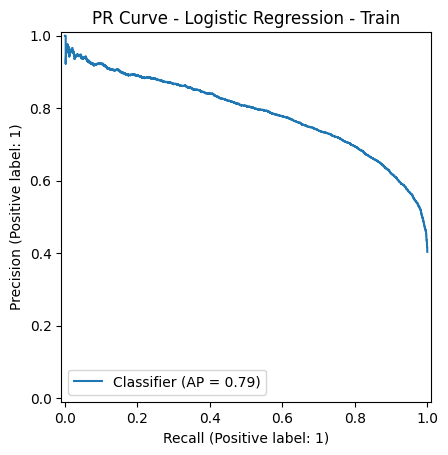


Confusion Matrix:
[[5475   47]
 [5962 2194]]


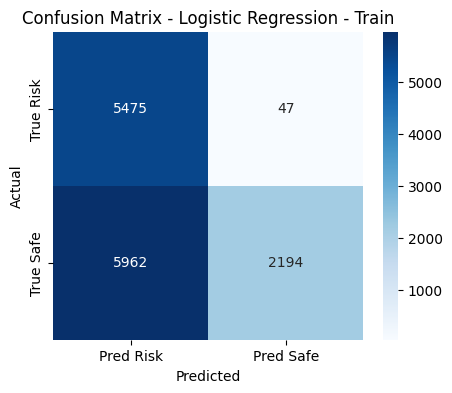


===== Logistic Regression - Validation =====
Threshold used: 0.2
Accuracy : 0.5284885704537701
Precision: 0.4598304400484457
Recall   : 0.9628064243448858
F1-score : 0.6224043715846994

Classification Report:
              precision    recall  f1-score   support

        Risk       0.46      0.96      0.62      1183
        Safe       0.90      0.23      0.37      1748

    accuracy                           0.53      2931
   macro avg       0.68      0.60      0.50      2931
weighted avg       0.72      0.53      0.47      2931

ROC-AUC  : 0.7385070922740348
PR-AUC   : 0.6385509878929858


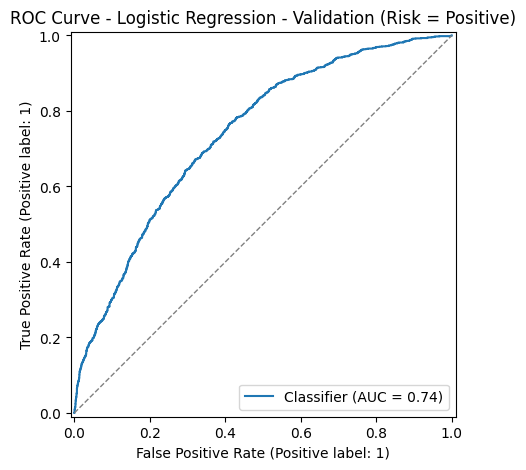

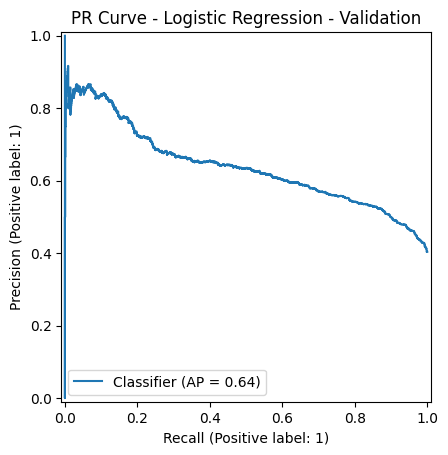


Confusion Matrix:
[[1139   44]
 [1338  410]]


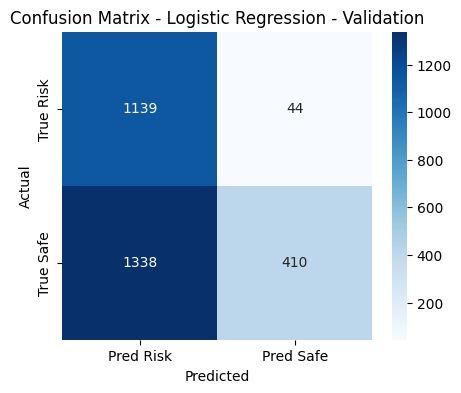


===== Logistic Regression - Test =====
Threshold used: 0.2
Accuracy : 0.5308768338451041
Precision: 0.4613829357056207
Recall   : 0.9636824324324325
F1-score : 0.6240087503418102

Classification Report:
              precision    recall  f1-score   support

        Risk       0.46      0.96      0.62      1184
        Safe       0.91      0.24      0.38      1747

    accuracy                           0.53      2931
   macro avg       0.68      0.60      0.50      2931
weighted avg       0.73      0.53      0.48      2931

ROC-AUC  : 0.7395356325128792
PR-AUC   : 0.6334576694449421


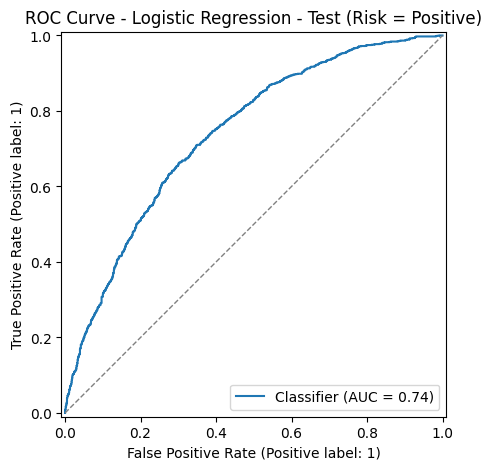

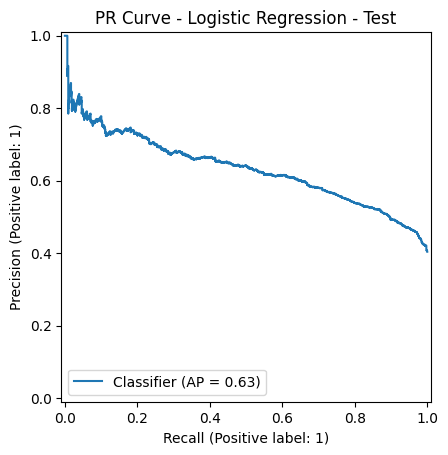


Confusion Matrix:
[[1141   43]
 [1332  415]]


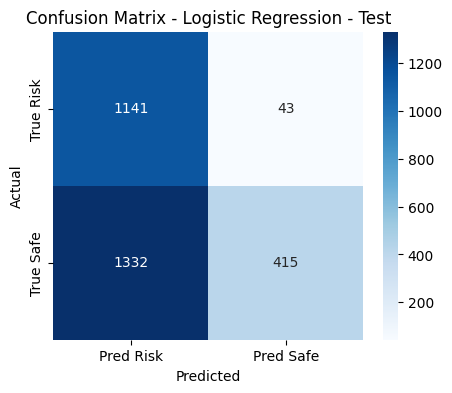

In [37]:
# Train evaluation
log_train_preds, log_train_scores = evaluate_logistic(
    "Logistic Regression - Train",
    X_train_sc,
    y_train,
    log_model,
    threshold=best_t_log
)

# Validation evaluation
log_val_preds, log_val_scores = evaluate_logistic(
    "Logistic Regression - Validation",
    X_val_sc,
    y_val,
    log_model,
    threshold=best_t_log
)

# Test evaluation
log_test_preds, log_test_scores = evaluate_logistic(
    "Logistic Regression - Test",
    X_test_sc,
    y_test,
    log_model,
    threshold=best_t_log
)

### Ensemble

In [38]:
import numpy as np
from sklearn.metrics import fbeta_score

weights = np.linspace(0, 1, 101)
thresholds = np.linspace(0.1, 0.9, 81)

best_w = None
best_t = None
best_score = -1

for w in weights:
    proba_ens = (
        w * proba_risk_ridge +
        (1 - w) * proba_risk_log
    )

    for t in thresholds:

        # predict Risk (0) if prob >= threshold
        y_pred = np.where(proba_ens >= t, 0, 1)

        score = fbeta_score(
            y_val,
            y_pred,
            beta=2,
            pos_label=0
        )

        if score > best_score:
            best_score = score
            best_w = w
            best_t = t

print("Best Ridge weight:", best_w)
print("Best Logistic weight:", 1 - best_w)
print("Best threshold:", best_t)
print("Best F2 score:", best_score)

Best Ridge weight: 0.04
Best Logistic weight: 0.96
Best threshold: 0.2
Best F2 score: 0.7904590209402302


In [39]:
np.corrcoef(proba_risk_ridge, proba_risk_log)

array([[1.        , 0.99199944],
       [0.99199944, 1.        ]])

The optimal ensemble heavily favors Logistic Regression (0.95 vs 0.05), and the near-perfect correlation (~0.997) between Ridge and Logistic predictions shows they are almost redundant. So, ensembling adds negligible diversity and is unlikely to provide meaningful gain over using Logistic Regression alone.

Ridge + calibration is often redundant because RidgeClassifier is not inherently probabilistic, and calibration does not consistently improve ranking performance. Logistic regression already produces well-calibrated probabilities, so extra calibration adds little value. Moreover, Ridge and logistic are highly correlated linear models, so ensembling them yields limited gains since effective ensembles rely on diverse, uncorrelated errors.

### Comparison of Ridge vs Logistic Regression

In [40]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

def get_metrics(name, y_true, proba_risk):

    # predictions at default threshold 0.5
    y_pred = np.where(proba_risk >= 0.5, 0, 1)

    # basic metrics (Risk = class 0)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label=0, zero_division=0)
    rec = recall_score(y_true, y_pred, pos_label=0, zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label=0, zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

    # confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    TP, FN = cm[0, 0], cm[0, 1]
    FP, TN = cm[1, 0], cm[1, 1]

    false_alarms_per_100 = (FP / (FP + TN) * 100) if (FP + TN) > 0 else 0
    missed_risks_per_100 = (FN / (FN + TP) * 100) if (FN + TP) > 0 else 0

    # ranking metrics (no threshold dependency)
    y_risk = (y_true == 0).astype(int)

    roc = roc_auc_score(y_risk, proba_risk)
    pr = average_precision_score(y_risk, proba_risk)

    return [
        name,
        acc,
        prec,
        rec,
        f1,
        f1_macro,
        roc,
        pr,
        int(false_alarms_per_100),
        int(missed_risks_per_100)
    ]

results = []

results.append(
    get_metrics("Ridge (Calibrated)", y_val, proba_risk_ridge)
)

results.append(
    get_metrics("Logistic Regression", y_val, proba_risk_log)
)

df_compare = pd.DataFrame(results, columns=[
    "Model",
    "Accuracy",
    "Precision (Risk)",
    "Recall (Risk)",
    "F1 (Risk)",
    "F1 Macro",
    "ROC-AUC",
    "PR-AUC",
    "False Alarms per 100",
    "Missed Risks per 100"
])

df_compare = df_compare.round(5)

df_compare

,Model,Accuracy,Precision (Risk),Recall (Risk),F1 (Risk),F1 Macro,ROC-AUC,PR-AUC,False Alarms per 100,Missed Risks per 100
0,Ridge (Calibrated),0.68236,0.64789,0.46661,0.54251,0.64962,0.73824,0.63698,17,53
1,Logistic Regression,0.67554,0.58761,0.65765,0.62066,0.66860,0.73851,0.63855,31,34
